---
title: "ClimateKG Graph Visualisation"
format:
  html:
    code-fold: true
execute:
  enabled: false
---

Generates graph visualisations of the ClimateKG knowledge graph by querying the PROD Wikibase SPARQL endpoint.

Each section provides:
- A copy-paste SPARQL query for the **Wikibase Query UI** (switch display to **Graph** mode)
- A direct deep-link to open the query in the UI
- A Python-rendered version using `pyvis` / `networkx` for offline use

**Wikibase Query UI**: <https://prod-climatekg.semanticclimate.org/query/>  
**SPARQL endpoint**: `https://prod-climatekg.semanticclimate.org/query/proxy/sparql`

**📓 Download Notebook**: [graph-visualisation.ipynb](https://github.com/TIBHannover/ClimateKG-Data-Bench/blob/main/sparql_queries/graph-visualisation.ipynb)

---

### Graph visualisation mode in the Wikibase Query UI

After running any query in the UI, click the **display type** button (bottom-left, default is Table) and select **Graph**.  
The graph builder reads `?item` as the source node and `?linkTo` as the target node.  
Node labels come from `?itemLabel` / `?linkToLabel`.

## Setup

In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
from IPython.display import display, Markdown, HTML
import urllib.parse

SPARQL_ENDPOINT = "https://prod-climatekg.semanticclimate.org/query/proxy/sparql"
QUERY_UI_BASE   = "https://prod-climatekg.semanticclimate.org/query/#"
WIKIBASE_URL    = "https://prod-climatekg.semanticclimate.org"

def run_query(sparql_query: str) -> pd.DataFrame:
    """Execute a SPARQL SELECT query and return results as a DataFrame."""
    sparql = SPARQLWrapper(SPARQL_ENDPOINT)
    sparql.setQuery(sparql_query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()
    bindings = results["results"]["bindings"]
    if not bindings:
        return pd.DataFrame()
    return pd.DataFrame([
        {k: v["value"] for k, v in row.items()}
        for row in bindings
    ])

def query_ui_link(sparql_query: str, label: str = "Open in Wikibase Query UI") -> str:
    """Return a Markdown link that opens the query in the Wikibase Query UI."""
    url = QUERY_UI_BASE + urllib.parse.quote(sparql_query, safe='')
    return f"[{label}]({url})"

print(f"Endpoint: {SPARQL_ENDPOINT}")


Endpoint: https://prod-climatekg.semanticclimate.org/query/proxy/sparql


***
## 1. Corpus Hierarchy Graph

Shows the **Part of** (`P3`) relationships that form the corpus backbone:
`Chapter → Text Division → Report → Report Series → Work`

This is the most readable full-data graph: every node is a real Wikibase item, every edge is a `P3` triple.

> **Tip:** In the Query UI, switch to **Graph** display mode after running.

In [2]:
HIERARCHY_QUERY = f"""
PREFIX wd:   <{WIKIBASE_URL}/entity/>
PREFIX wdt:  <{WIKIBASE_URL}/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {{
  ?item wdt:P3 ?linkTo .

  # Only include corpus-layer items (Work / Report Series / Report / Text Division / Chapter)
  VALUES ?allowedClass {{ wd:Q2 wd:Q3 wd:Q4 wd:Q5 wd:Q6 }}
  ?item  wdt:P1 ?allowedClass .

  OPTIONAL {{ ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }}
  OPTIONAL {{ ?linkTo rdfs:label ?linkToLabel . FILTER(LANG(?linkToLabel) = "en") }}
}}
ORDER BY ?linkToLabel ?itemLabel
"""

display(Markdown(query_ui_link(HIERARCHY_QUERY, "Open Corpus Hierarchy query in Wikibase Query UI")))
print("\n--- SPARQL (copy into Query UI, then switch display to 'Graph') ---\n")
print(HIERARCHY_QUERY)

[Open Corpus Hierarchy query in Wikibase Query UI](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%20%20%3Fitem%20wdt%3AP3%20%3FlinkTo%20.%0A%0A%20%20%23%20Only%20include%20corpus-layer%20items%20%28Work%20%2F%20Report%20Series%20%2F%20Report%20%2F%20Text%20Division%20%2F%20Chapter%29%0A%20%20VALUES%20%3FallowedClass%20%7B%20wd%3AQ2%20wd%3AQ3%20wd%3AQ4%20wd%3AQ5%20wd%3AQ6%20%7D%0A%20%20%3Fitem%20%20wdt%3AP1%20%3FallowedClass%20.%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0AORDER%20BY%20%3FlinkToLabel%20%3FitemLabel%0A)


--- SPARQL (copy into Query UI, then switch display to 'Graph') ---


PREFIX wd:   <https://prod-climatekg.semanticclimate.org/entity/>
PREFIX wdt:  <https://prod-climatekg.semanticclimate.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {
  ?item wdt:P3 ?linkTo .

  # Only include corpus-layer items (Work / Report Series / Report / Text Division / Chapter)
  VALUES ?allowedClass { wd:Q2 wd:Q3 wd:Q4 wd:Q5 wd:Q6 }
  ?item  wdt:P1 ?allowedClass .

  OPTIONAL { ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }
  OPTIONAL { ?linkTo rdfs:label ?linkToLabel . FILTER(LANG(?linkToLabel) = "en") }
}
ORDER BY ?linkToLabel ?itemLabel



In [3]:
df_hier = run_query(HIERARCHY_QUERY)
print(f"Edges returned: {len(df_hier)}")
display(df_hier.head(20))

Edges returned: 105


,item,itemLabel,linkTo,linkToLabel
0,https://prod-climatekg.semanticclimate.org/ent...,Atlas,https://prod-climatekg.semanticclimate.org/ent...,Atlas
1,https://prod-climatekg.semanticclimate.org/ent...,Accelerating the Transition in the Context of ...,https://prod-climatekg.semanticclimate.org/ent...,Chapters
2,https://prod-climatekg.semanticclimate.org/ent...,Africa,https://prod-climatekg.semanticclimate.org/ent...,Chapters
3,https://prod-climatekg.semanticclimate.org/ent...,"Agriculture, Forestry and Other Land Uses (AFOLU)",https://prod-climatekg.semanticclimate.org/ent...,Chapters
4,https://prod-climatekg.semanticclimate.org/ent...,Asia,https://prod-climatekg.semanticclimate.org/ent...,Chapters
5,https://prod-climatekg.semanticclimate.org/ent...,Australasia,https://prod-climatekg.semanticclimate.org/ent...,Chapters
6,https://prod-climatekg.semanticclimate.org/ent...,Buildings,https://prod-climatekg.semanticclimate.org/ent...,Chapters
7,https://prod-climatekg.semanticclimate.org/ent...,Central and South America,https://prod-climatekg.semanticclimate.org/ent...,Chapters
8,https://prod-climatekg.semanticclimate.org/ent...,"Changing Ocean, Marine Ecosystems, and Depende...",https://prod-climatekg.semanticclimate.org/ent...,Chapters
9,https://prod-climatekg.semanticclimate.org/ent...,Changing State of the Climate System,https://prod-climatekg.semanticclimate.org/ent...,Chapters


### 1b. Python graph render (pyvis)

Renders the same hierarchy as an interactive HTML graph using `pyvis`.  
Nodes are colour-coded by class (`P1`).

In [4]:
# Install if needed: pip install pyvis networkx
from pyvis.network import Network
import networkx as nx

# Fetch labels + class for colour coding
CLASS_QUERY = f"""
PREFIX wd:   <{WIKIBASE_URL}/entity/>
PREFIX wdt:  <{WIKIBASE_URL}/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel ?classQid WHERE {{
  VALUES ?classQid {{ wd:Q2 wd:Q3 wd:Q4 wd:Q5 wd:Q6 }}
  ?item wdt:P1 ?classQid .
  OPTIONAL {{ ?item rdfs:label ?itemLabel . FILTER(LANG(?itemLabel) = "en") }}
}}
"""

CLASS_COLOURS = {
    f"{WIKIBASE_URL}/entity/Q2": "#e74c3c",   # Work - red
    f"{WIKIBASE_URL}/entity/Q3": "#e67e22",   # Report Series - orange
    f"{WIKIBASE_URL}/entity/Q4": "#f1c40f",   # Report - yellow
    f"{WIKIBASE_URL}/entity/Q5": "#2ecc71",   # Text Division - green
    f"{WIKIBASE_URL}/entity/Q6": "#3498db",   # Chapter - blue
}
CLASS_LABELS = {
    f"{WIKIBASE_URL}/entity/Q2": "Work",
    f"{WIKIBASE_URL}/entity/Q3": "Report Series",
    f"{WIKIBASE_URL}/entity/Q4": "Report",
    f"{WIKIBASE_URL}/entity/Q5": "Text Division",
    f"{WIKIBASE_URL}/entity/Q6": "Chapter",
}

df_classes = run_query(CLASS_QUERY)
item_class  = dict(zip(df_classes["item"], df_classes["classQid"]))
item_label  = dict(zip(df_classes["item"], df_classes.get("itemLabel", df_classes["item"])))

G = nx.DiGraph()

for _, row in df_hier.iterrows():
    src = row["item"]
    tgt = row["linkTo"]
    src_label = item_label.get(src, src.split("/")[-1])
    tgt_label = item_label.get(tgt, tgt.split("/")[-1])
    G.add_node(src, label=src_label,
               color=CLASS_COLOURS.get(item_class.get(src, ""), "#95a5a6"),
               title=f"{src_label} ({CLASS_LABELS.get(item_class.get(src, ''), 'Unknown')})")
    G.add_node(tgt, label=tgt_label,
               color=CLASS_COLOURS.get(item_class.get(tgt, ""), "#95a5a6"),
               title=f"{tgt_label} ({CLASS_LABELS.get(item_class.get(tgt, ''), 'Unknown')})")
    G.add_edge(src, tgt, title="Part of")

net = Network(height="750px", width="100%", directed=True, notebook=True)
net.from_nx(G)
net.set_options("""
  var options = {
    "physics": { "hierarchicalRepulsion": { "centralGravity": 0.0 }, "solver": "hierarchicalRepulsion" },
    "layout":  { "hierarchical": { "enabled": true, "direction": "UD", "sortMethod": "directed" } },
    "edges":   { "arrows": { "to": { "enabled": true } } }
  }
""")

output_path = "../research_data/data-vis/visualization-outputs/corpus-hierarchy-graph.html"
net.save_graph(output_path)
display(HTML(f'<a href="{output_path}" target="_blank">Open corpus hierarchy graph</a>'))
net.show(output_path)

../research_data/data-vis/visualization-outputs/corpus-hierarchy-graph.html


***
## 2. Author–Chapter Contribution Graph

Shows **Authors** connected to the **Chapters** they contributed to via `P27` (contributed to chapter).  
Edge direction: Author → Chapter.

⚠️ Note: the PROD instance has a known duplicate import — authors were imported twice.  
The query deduplicates by `P20` (ClimateKG Author ID) to avoid doubled nodes.

In [5]:
AUTHOR_CHAPTER_QUERY = f"""
PREFIX wd:   <{WIKIBASE_URL}/entity/>
PREFIX wdt:  <{WIKIBASE_URL}/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {{

  # Deduplicate authors via P20 (ClimateKG Author ID)
  ?item wdt:P20 ?authorId .
  ?item wdt:P27 ?linkTo .
  ?linkTo wdt:P1 wd:Q6 .   # linkTo must be a Chapter

  OPTIONAL {{ ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }}
  OPTIONAL {{ ?linkTo rdfs:label ?linkToLabel . FILTER(LANG(?linkToLabel) = "en") }}
}}
ORDER BY ?itemLabel
"""

display(Markdown(query_ui_link(AUTHOR_CHAPTER_QUERY, "Open Author-Chapter query in Wikibase Query UI")))
print("\n--- SPARQL ---\n")
print(AUTHOR_CHAPTER_QUERY)

[Open Author-Chapter query in Wikibase Query UI](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%0A%20%20%23%20Deduplicate%20authors%20via%20P20%20%28ClimateKG%20Author%20ID%29%0A%20%20%3Fitem%20wdt%3AP20%20%3FauthorId%20.%0A%20%20%3Fitem%20wdt%3AP27%20%3FlinkTo%20.%0A%20%20%3FlinkTo%20wdt%3AP1%20wd%3AQ6%20.%20%20%20%23%20linkTo%20must%20be%20a%20Chapter%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0AORDER%20BY%20%3FitemLabel%0A)


--- SPARQL ---


PREFIX wd:   <https://prod-climatekg.semanticclimate.org/entity/>
PREFIX wdt:  <https://prod-climatekg.semanticclimate.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {

  # Deduplicate authors via P20 (ClimateKG Author ID)
  ?item wdt:P20 ?authorId .
  ?item wdt:P27 ?linkTo .
  ?linkTo wdt:P1 wd:Q6 .   # linkTo must be a Chapter

  OPTIONAL { ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }
  OPTIONAL { ?linkTo rdfs:label ?linkToLabel . FILTER(LANG(?linkToLabel) = "en") }
}
ORDER BY ?itemLabel



In [6]:
df_auth = run_query(AUTHOR_CHAPTER_QUERY)
print(f"Author-Chapter edges: {len(df_auth)}")
print(f"Unique authors:  {df_auth['item'].nunique()}")
print(f"Unique chapters: {df_auth['linkTo'].nunique()}")
display(df_auth.head(20))

Author-Chapter edges: 1164
Unique authors:  932
Unique chapters: 75


,item,itemLabel,linkTo,linkToLabel
0,https://prod-climatekg.semanticclimate.org/ent...,Adam Mohammed Sebbit,https://prod-climatekg.semanticclimate.org/ent...,Mitigation Pathways Compatible with Long-term ...
1,https://prod-climatekg.semanticclimate.org/ent...,Adelle Thomas,https://prod-climatekg.semanticclimate.org/ent...,Impacts of 1.5°C Global Warming on Natural and...
2,https://prod-climatekg.semanticclimate.org/ent...,Adelle Thomas,https://prod-climatekg.semanticclimate.org/ent...,Key Risks across Sectors and Regions
3,https://prod-climatekg.semanticclimate.org/ent...,Adelle Thomas,https://prod-climatekg.semanticclimate.org/ent...,Cities and Settlements by the Sea
4,https://prod-climatekg.semanticclimate.org/ent...,Aditi Mukherji,https://prod-climatekg.semanticclimate.org/ent...,High Mountain Areas
5,https://prod-climatekg.semanticclimate.org/ent...,Aditi Mukherji,https://prod-climatekg.semanticclimate.org/ent...,Water
6,https://prod-climatekg.semanticclimate.org/ent...,Aditi Mukherji,https://prod-climatekg.semanticclimate.org/ent...,Summary for Policymakers
7,https://prod-climatekg.semanticclimate.org/ent...,Aditi Mukherji,https://prod-climatekg.semanticclimate.org/ent...,Longer Report
8,https://prod-climatekg.semanticclimate.org/ent...,Adolf Acquaye,https://prod-climatekg.semanticclimate.org/ent...,Industry
9,https://prod-climatekg.semanticclimate.org/ent...,Adrian Leip,https://prod-climatekg.semanticclimate.org/ent...,Cross-sectoral Perspectives


***
## 3. Schema / Class-level Overview Graph

A **meta-graph** showing entity *classes* as nodes and the relationship *types* between them as edges.  
Uses `P1` (instance of) to infer which properties connect which class pairs.

This is the clearest overview for a report: small number of nodes, all structural relationships visible.

In [7]:
SCHEMA_QUERY = f"""
PREFIX wd:   <{WIKIBASE_URL}/entity/>
PREFIX wdt:  <{WIKIBASE_URL}/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?sourceClass ?sourceClassLabel ?propLabel ?targetClass ?targetClassLabel
  (COUNT(*) AS ?edgeCount)
WHERE {{
  # All WikibaseItem properties between items
  VALUES ?prop {{ wdt:P3 wdt:P4 wdt:P27 wdt:P12 }}

  ?subject  ?prop       ?object .
  ?subject  wdt:P1      ?sourceClass .
  ?object   wdt:P1      ?targetClass .

  OPTIONAL {{ ?sourceClass rdfs:label ?sourceClassLabel . FILTER(LANG(?sourceClassLabel) = "en") }}
  OPTIONAL {{ ?targetClass rdfs:label ?targetClassLabel . FILTER(LANG(?targetClassLabel) = "en") }}

  # Rewrite prop URI to a readable label
  BIND(
    IF(?prop = wdt:P3,  "Part of",
    IF(?prop = wdt:P4,  "Has parts",
    IF(?prop = wdt:P27, "contributed to chapter",
    IF(?prop = wdt:P12, "Has TAG", STR(?prop)))))
  AS ?propLabel)
}}
GROUP BY ?sourceClass ?sourceClassLabel ?propLabel ?targetClass ?targetClassLabel
ORDER BY DESC(?edgeCount)
"""

display(Markdown(query_ui_link(SCHEMA_QUERY, "Open Schema graph query in Wikibase Query UI")))
print("\n--- SPARQL ---\n")
print(SCHEMA_QUERY)

[Open Schema graph query in Wikibase Query UI](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3FsourceClass%20%3FsourceClassLabel%20%3FpropLabel%20%3FtargetClass%20%3FtargetClassLabel%0A%20%20%28COUNT%28%2A%29%20AS%20%3FedgeCount%29%0AWHERE%20%7B%0A%20%20%23%20All%20WikibaseItem%20properties%20between%20items%0A%20%20VALUES%20%3Fprop%20%7B%20wdt%3AP3%20wdt%3AP4%20wdt%3AP27%20wdt%3AP12%20%7D%0A%0A%20%20%3Fsubject%20%20%3Fprop%20%20%20%20%20%20%20%3Fobject%20.%0A%20%20%3Fsubject%20%20wdt%3AP1%20%20%20%20%20%20%3FsourceClass%20.%0A%20%20%3Fobject%20%20%20wdt%3AP1%20%20%20%20%20%20%3FtargetClass%20.%0A%0A%20%20OPTIONAL%20%7B%20%3FsourceClass%20rdfs%3Alabel%20%3FsourceClassLabel%20.%20FILTER%28LANG%28%3FsourceClassLabel%29%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FtargetClass%20rdfs%3Alabel%20%3FtargetClassLabel%20.%20FILTER%28LANG%28%3FtargetClassLabel%29%20%3D%20%22en%22%29%20%7D%0A%0A%20%20%23%20Rewrite%20prop%20URI%20to%20a%20readable%20label%0A%20%20BIND%28%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP3%2C%20%20%22Part%20of%22%2C%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP4%2C%20%20%22Has%20parts%22%2C%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP27%2C%20%22contributed%20to%20chapter%22%2C%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP12%2C%20%22Has%20TAG%22%2C%20STR%28%3Fprop%29%29%29%29%29%0A%20%20AS%20%3FpropLabel%29%0A%7D%0AGROUP%20BY%20%3FsourceClass%20%3FsourceClassLabel%20%3FpropLabel%20%3FtargetClass%20%3FtargetClassLabel%0AORDER%20BY%20DESC%28%3FedgeCount%29%0A)


--- SPARQL ---


PREFIX wd:   <https://prod-climatekg.semanticclimate.org/entity/>
PREFIX wdt:  <https://prod-climatekg.semanticclimate.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?sourceClass ?sourceClassLabel ?propLabel ?targetClass ?targetClassLabel
  (COUNT(*) AS ?edgeCount)
WHERE {
  # All WikibaseItem properties between items
  VALUES ?prop { wdt:P3 wdt:P4 wdt:P27 wdt:P12 }

  ?subject  ?prop       ?object .
  ?subject  wdt:P1      ?sourceClass .
  ?object   wdt:P1      ?targetClass .

  OPTIONAL { ?sourceClass rdfs:label ?sourceClassLabel . FILTER(LANG(?sourceClassLabel) = "en") }
  OPTIONAL { ?targetClass rdfs:label ?targetClassLabel . FILTER(LANG(?targetClassLabel) = "en") }

  # Rewrite prop URI to a readable label
  BIND(
    IF(?prop = wdt:P3,  "Part of",
    IF(?prop = wdt:P4,  "Has parts",
    IF(?prop = wdt:P27, "contributed to chapter",
    IF(?prop = wdt:P12, "Has TAG", STR(?prop)))))
  AS ?propLabel)
}
GROUP BY ?sourceClass

In [8]:
df_schema = run_query(SCHEMA_QUERY)
display(df_schema)

,sourceClass,sourceClassLabel,propLabel,targetClass,edgeCount,targetClassLabel
0,https://prod-climatekg.semanticclimate.org/ent...,Acronym,Part of,https://prod-climatekg.semanticclimate.org/ent...,2993,NaN
1,https://prod-climatekg.semanticclimate.org/ent...,Category,Part of,https://prod-climatekg.semanticclimate.org/ent...,1361,NaN
2,https://prod-climatekg.semanticclimate.org/ent...,Author,contributed to chapter,https://prod-climatekg.semanticclimate.org/ent...,1164,Chapter
3,https://prod-climatekg.semanticclimate.org/ent...,Chapter,Has TAG,https://prod-climatekg.semanticclimate.org/ent...,264,Category
4,https://prod-climatekg.semanticclimate.org/ent...,Chapter,Part of,https://prod-climatekg.semanticclimate.org/ent...,75,NaN
5,https://prod-climatekg.semanticclimate.org/ent...,Author,contributed to chapter,https://prod-climatekg.semanticclimate.org/ent...,19,NaN
6,https://prod-climatekg.semanticclimate.org/ent...,Chapter,Part of,https://prod-climatekg.semanticclimate.org/ent...,14,NaN
7,https://prod-climatekg.semanticclimate.org/ent...,NaN,Has TAG,https://prod-climatekg.semanticclimate.org/ent...,13,Category
8,https://prod-climatekg.semanticclimate.org/ent...,NaN,Part of,https://prod-climatekg.semanticclimate.org/ent...,10,NaN
9,https://prod-climatekg.semanticclimate.org/ent...,NaN,Part of,https://prod-climatekg.semanticclimate.org/ent...,7,NaN


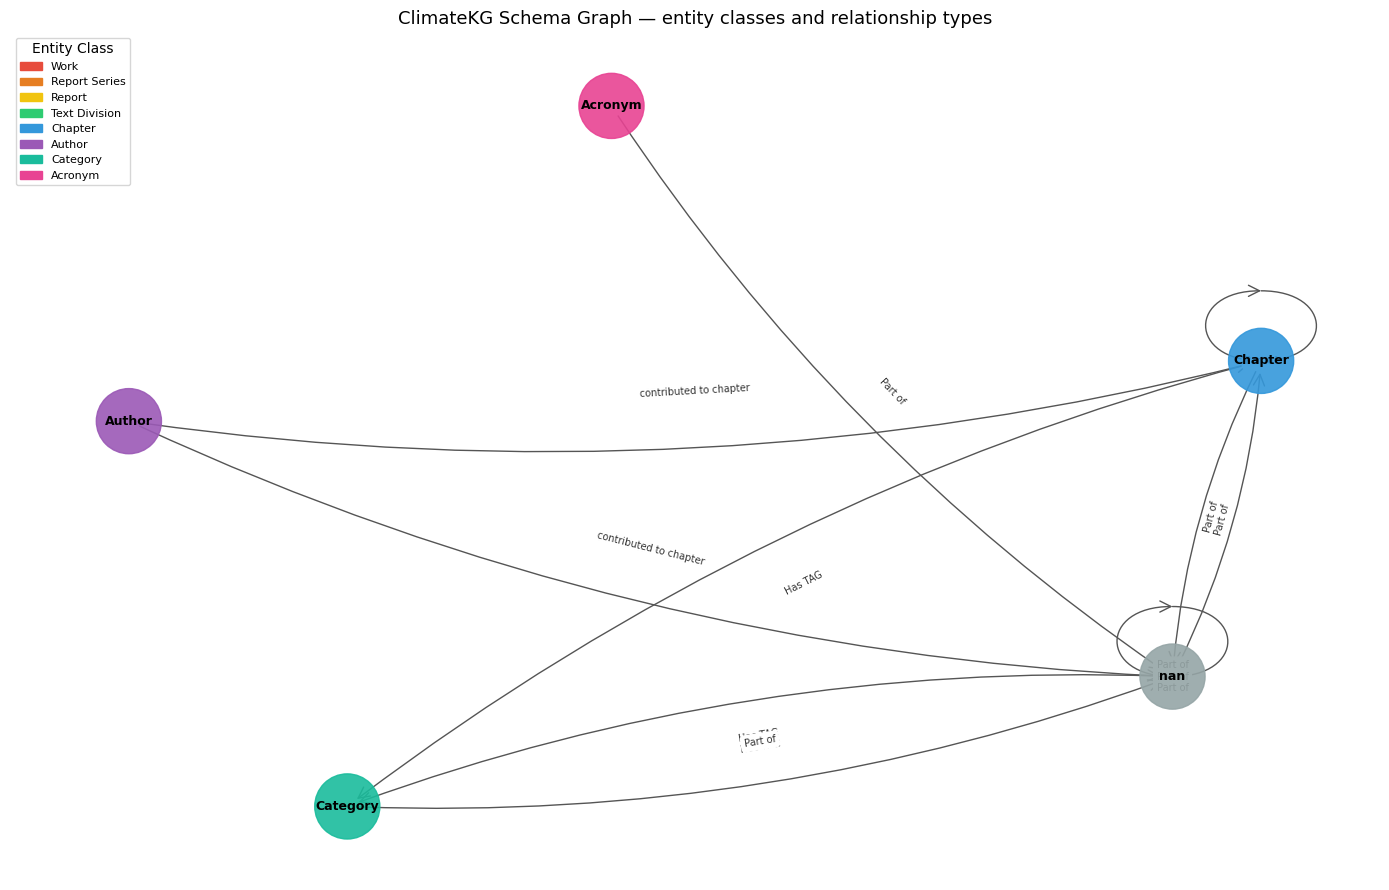

Saved: ../research_data/data-vis/visualization-outputs/schema-graph.png


In [9]:
# Render schema graph with matplotlib + networkx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SCHEMA_COLOURS = {
    "Work":            "#e74c3c",
    "Report Series":   "#e67e22",
    "Report":          "#f1c40f",
    "Text Division":   "#2ecc71",
    "Chapter":         "#3498db",
    "Author":          "#9b59b6",
    "Category":        "#1abc9c",   # Glossary Term
    "Acronym":         "#e84393",
}

G_schema = nx.DiGraph()

for _, row in df_schema.iterrows():
    src = row.get("sourceClassLabel", row["sourceClass"].split("/")[-1])
    tgt = row.get("targetClassLabel", row["targetClass"].split("/")[-1])
    edge_label = row.get("propLabel", "?")
    count = int(row.get("edgeCount", 0))

    G_schema.add_node(src, color=SCHEMA_COLOURS.get(src, "#95a5a6"))
    G_schema.add_node(tgt, color=SCHEMA_COLOURS.get(tgt, "#95a5a6"))
    if G_schema.has_edge(src, tgt):
        G_schema[src][tgt]["label"] += f"\n{edge_label}"
        G_schema[src][tgt]["count"] += count
    else:
        G_schema.add_edge(src, tgt, label=edge_label, count=count)

pos = nx.spring_layout(G_schema, seed=42, k=3)
node_colors = [G_schema.nodes[n].get("color", "#95a5a6") for n in G_schema.nodes()]
edge_labels = {(u, v): d["label"] for u, v, d in G_schema.edges(data=True)}

fig, ax = plt.subplots(figsize=(14, 9))
nx.draw_networkx_nodes(G_schema, pos, node_color=node_colors, node_size=2200, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G_schema, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G_schema, pos, arrows=True, arrowstyle="->",
                       arrowsize=20, edge_color="#555",
                       connectionstyle="arc3,rad=0.1", ax=ax)
nx.draw_networkx_edge_labels(G_schema, pos, edge_labels=edge_labels,
                             font_size=7, font_color="#333", ax=ax)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in SCHEMA_COLOURS.items()]
ax.legend(handles=legend_patches, loc="upper left", fontsize=8, title="Entity Class")
ax.set_title("ClimateKG Schema Graph — entity classes and relationship types", fontsize=13)
ax.axis("off")

out_path = "../research_data/data-vis/visualization-outputs/schema-graph.png"
plt.tight_layout()
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved: {out_path}")

***
## 4. Full Knowledge Graph — All Item-to-Item Triples

Queries every triple where both subject and object are Wikibase items.  
Includes `P3`, `P4`, `P12`, `P27`.  

⚠️ This returns thousands of rows. Use `LIMIT` for the Query UI graph — the UI renders up to ~500 nodes comfortably.

In [10]:
FULL_GRAPH_QUERY = f"""
PREFIX wd:   <{WIKIBASE_URL}/entity/>
PREFIX wdt:  <{WIKIBASE_URL}/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

# ------------------------------------------------------------------
# Full knowledge graph: all item-to-item relationships.
# Switch display to 'Graph' in the Wikibase Query UI.
# Adjust LIMIT for performance; 500 is comfortable in the browser.
# ------------------------------------------------------------------
SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {{

  VALUES ?prop {{ wdt:P3 wdt:P4 wdt:P12 wdt:P27 }}
  ?item  ?prop   ?linkTo .

  # Restrict to known entity classes to exclude stray items
  VALUES ?srcClass {{ wd:Q2 wd:Q3 wd:Q4 wd:Q5 wd:Q6 wd:Q2087 wd:Q3998 wd:Q1 }}
  ?item  wdt:P1  ?srcClass .

  # Deduplicate authors by P20
  OPTIONAL {{ ?item wdt:P20 ?authorId }}

  OPTIONAL {{ ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }}
  OPTIONAL {{ ?linkTo rdfs:label ?linkToLabel . FILTER(LANG(?linkToLabel) = "en") }}
}}
LIMIT 500
"""

display(Markdown(query_ui_link(FULL_GRAPH_QUERY, "Open Full Graph query in Wikibase Query UI (500-edge sample)")))
print("\n--- SPARQL ---\n")
print(FULL_GRAPH_QUERY)

[Open Full Graph query in Wikibase Query UI (500-edge sample)](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0A%23%20------------------------------------------------------------------%0A%23%20Full%20knowledge%20graph%3A%20all%20item-to-item%20relationships.%0A%23%20Switch%20display%20to%20%27Graph%27%20in%20the%20Wikibase%20Query%20UI.%0A%23%20Adjust%20LIMIT%20for%20performance%3B%20500%20is%20comfortable%20in%20the%20browser.%0A%23%20------------------------------------------------------------------%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%0A%20%20VALUES%20%3Fprop%20%7B%20wdt%3AP3%20wdt%3AP4%20wdt%3AP12%20wdt%3AP27%20%7D%0A%20%20%3Fitem%20%20%3Fprop%20%20%20%3FlinkTo%20.%0A%0A%20%20%23%20Restrict%20to%20known%20entity%20classes%20to%20exclude%20stray%20items%0A%20%20VALUES%20%3FsrcClass%20%7B%20wd%3AQ2%20wd%3AQ3%20wd%3AQ4%20wd%3AQ5%20wd%3AQ6%20wd%3AQ2087%20wd%3AQ3998%20wd%3AQ1%20%7D%0A%20%20%3Fitem%20%20wdt%3AP1%20%20%3FsrcClass%20.%0A%0A%20%20%23%20Deduplicate%20authors%20by%20P20%0A%20%20OPTIONAL%20%7B%20%3Fitem%20wdt%3AP20%20%3FauthorId%20%7D%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0ALIMIT%20500%0A)


--- SPARQL ---


PREFIX wd:   <https://prod-climatekg.semanticclimate.org/entity/>
PREFIX wdt:  <https://prod-climatekg.semanticclimate.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

# ------------------------------------------------------------------
# Full knowledge graph: all item-to-item relationships.
# Switch display to 'Graph' in the Wikibase Query UI.
# Adjust LIMIT for performance; 500 is comfortable in the browser.
# ------------------------------------------------------------------
SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {

  VALUES ?prop { wdt:P3 wdt:P4 wdt:P12 wdt:P27 }
  ?item  ?prop   ?linkTo .

  # Restrict to known entity classes to exclude stray items
  VALUES ?srcClass { wd:Q2 wd:Q3 wd:Q4 wd:Q5 wd:Q6 wd:Q2087 wd:Q3998 wd:Q1 }
  ?item  wdt:P1  ?srcClass .

  # Deduplicate authors by P20
  OPTIONAL { ?item wdt:P20 ?authorId }

  OPTIONAL { ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }
  OPTIONAL { ?l

***
## 5. Glossary Terms linked to Reports

Shows which **Glossary Terms** (`Q1`) are associated with which **Reports** (`Q4`) via `P3` (Part of / series_ref).

In [11]:
GLOSSARY_QUERY = f"""
PREFIX wd:   <{WIKIBASE_URL}/entity/>
PREFIX wdt:  <{WIKIBASE_URL}/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {{
  ?item  wdt:P1 wd:Q1 .      # Glossary Term
  ?item  wdt:P3 ?linkTo .   # Part of -> Report
  ?linkTo wdt:P1 wd:Q4 .      # target must be a Report

  OPTIONAL {{ ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }}
  OPTIONAL {{ ?linkTo rdfs:label ?linkToLabel . FILTER(LANG(?linkToLabel) = "en") }}
}}
ORDER BY ?linkToLabel ?itemLabel
"""

display(Markdown(query_ui_link(GLOSSARY_QUERY, "Open Glossary-Report graph in Wikibase Query UI")))
print("\n--- SPARQL ---\n")
print(GLOSSARY_QUERY)

[Open Glossary-Report graph in Wikibase Query UI](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%20%20%3Fitem%20%20wdt%3AP1%20wd%3AQ1%20.%20%20%20%20%20%20%23%20Glossary%20Term%0A%20%20%3Fitem%20%20wdt%3AP3%20%3FlinkTo%20.%20%20%20%23%20Part%20of%20-%3E%20Report%0A%20%20%3FlinkTo%20wdt%3AP1%20wd%3AQ4%20.%20%20%20%20%20%20%23%20target%20must%20be%20a%20Report%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0AORDER%20BY%20%3FlinkToLabel%20%3FitemLabel%0A)


--- SPARQL ---


PREFIX wd:   <https://prod-climatekg.semanticclimate.org/entity/>
PREFIX wdt:  <https://prod-climatekg.semanticclimate.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?item ?itemLabel ?linkTo ?linkToLabel WHERE {
  ?item  wdt:P1 wd:Q1 .      # Glossary Term
  ?item  wdt:P3 ?linkTo .   # Part of -> Report
  ?linkTo wdt:P1 wd:Q4 .      # target must be a Report

  OPTIONAL { ?item   rdfs:label ?itemLabel   . FILTER(LANG(?itemLabel)   = "en") }
  OPTIONAL { ?linkTo rdfs:label ?linkToLabel . FILTER(LANG(?linkToLabel) = "en") }
}
ORDER BY ?linkToLabel ?itemLabel



In [12]:
df_gloss = run_query(GLOSSARY_QUERY)
print(f"Glossary term-Report edges: {len(df_gloss)}")
print(f"Unique terms:   {df_gloss['item'].nunique() if not df_gloss.empty else 0}")
print(f"Unique reports: {df_gloss['linkTo'].nunique() if not df_gloss.empty else 0}")
display(df_gloss.head(20))

Glossary term-Report edges: 1361
Unique terms:   913
Unique reports: 4


,item,itemLabel,linkTo,linkToLabel
0,https://prod-climatekg.semanticclimate.org/ent...,1.5°C warmer worlds,https://prod-climatekg.semanticclimate.org/ent...,Special Report: Global Warming of 1.5°C
1,https://prod-climatekg.semanticclimate.org/ent...,1.5°C pathway,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
2,https://prod-climatekg.semanticclimate.org/ent...,13C,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
3,https://prod-climatekg.semanticclimate.org/ent...,14C,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
4,https://prod-climatekg.semanticclimate.org/ent...,Ablation,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
5,https://prod-climatekg.semanticclimate.org/ent...,Abrupt change,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
6,https://prod-climatekg.semanticclimate.org/ent...,Abrupt climate change,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
7,https://prod-climatekg.semanticclimate.org/ent...,Accumulation,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
8,https://prod-climatekg.semanticclimate.org/ent...,Active layer,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...
9,https://prod-climatekg.semanticclimate.org/ent...,Adaptation,https://prod-climatekg.semanticclimate.org/ent...,Working Group I: Climate Change 2021 – The Phy...


***
## Query UI Links Summary

All queries ready to open directly in the Wikibase Query UI.  
After opening, click the **display mode** button (bottom-left of the results panel) and select **Graph**.

In [13]:
links_md = "| Graph | Query UI link |\n|---|---|\n"
entries = [
    ("1. Corpus hierarchy (Part of)",        HIERARCHY_QUERY),
    ("2. Author-Chapter contributions",       AUTHOR_CHAPTER_QUERY),
    ("3. Schema / class-level overview",      SCHEMA_QUERY),
    ("4. Full KG (500-edge sample)",          FULL_GRAPH_QUERY),
    ("5. Glossary Terms linked to Reports",   GLOSSARY_QUERY),
]
for label, q in entries:
    url = QUERY_UI_BASE + urllib.parse.quote(q, safe='')
    links_md += f"| {label} | [Open]({url}) |\n"

display(Markdown(links_md))

| Graph | Query UI link |
|---|---|
| 1. Corpus hierarchy (Part of) | [Open](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%20%20%3Fitem%20wdt%3AP3%20%3FlinkTo%20.%0A%0A%20%20%23%20Only%20include%20corpus-layer%20items%20%28Work%20%2F%20Report%20Series%20%2F%20Report%20%2F%20Text%20Division%20%2F%20Chapter%29%0A%20%20VALUES%20%3FallowedClass%20%7B%20wd%3AQ2%20wd%3AQ3%20wd%3AQ4%20wd%3AQ5%20wd%3AQ6%20%7D%0A%20%20%3Fitem%20%20wdt%3AP1%20%3FallowedClass%20.%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0AORDER%20BY%20%3FlinkToLabel%20%3FitemLabel%0A) |
| 2. Author-Chapter contributions | [Open](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%0A%20%20%23%20Deduplicate%20authors%20via%20P20%20%28ClimateKG%20Author%20ID%29%0A%20%20%3Fitem%20wdt%3AP20%20%3FauthorId%20.%0A%20%20%3Fitem%20wdt%3AP27%20%3FlinkTo%20.%0A%20%20%3FlinkTo%20wdt%3AP1%20wd%3AQ6%20.%20%20%20%23%20linkTo%20must%20be%20a%20Chapter%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0AORDER%20BY%20%3FitemLabel%0A) |
| 3. Schema / class-level overview | [Open](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3FsourceClass%20%3FsourceClassLabel%20%3FpropLabel%20%3FtargetClass%20%3FtargetClassLabel%0A%20%20%28COUNT%28%2A%29%20AS%20%3FedgeCount%29%0AWHERE%20%7B%0A%20%20%23%20All%20WikibaseItem%20properties%20between%20items%0A%20%20VALUES%20%3Fprop%20%7B%20wdt%3AP3%20wdt%3AP4%20wdt%3AP27%20wdt%3AP12%20%7D%0A%0A%20%20%3Fsubject%20%20%3Fprop%20%20%20%20%20%20%20%3Fobject%20.%0A%20%20%3Fsubject%20%20wdt%3AP1%20%20%20%20%20%20%3FsourceClass%20.%0A%20%20%3Fobject%20%20%20wdt%3AP1%20%20%20%20%20%20%3FtargetClass%20.%0A%0A%20%20OPTIONAL%20%7B%20%3FsourceClass%20rdfs%3Alabel%20%3FsourceClassLabel%20.%20FILTER%28LANG%28%3FsourceClassLabel%29%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FtargetClass%20rdfs%3Alabel%20%3FtargetClassLabel%20.%20FILTER%28LANG%28%3FtargetClassLabel%29%20%3D%20%22en%22%29%20%7D%0A%0A%20%20%23%20Rewrite%20prop%20URI%20to%20a%20readable%20label%0A%20%20BIND%28%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP3%2C%20%20%22Part%20of%22%2C%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP4%2C%20%20%22Has%20parts%22%2C%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP27%2C%20%22contributed%20to%20chapter%22%2C%0A%20%20%20%20IF%28%3Fprop%20%3D%20wdt%3AP12%2C%20%22Has%20TAG%22%2C%20STR%28%3Fprop%29%29%29%29%29%0A%20%20AS%20%3FpropLabel%29%0A%7D%0AGROUP%20BY%20%3FsourceClass%20%3FsourceClassLabel%20%3FpropLabel%20%3FtargetClass%20%3FtargetClassLabel%0AORDER%20BY%20DESC%28%3FedgeCount%29%0A) |
| 4. Full KG (500-edge sample) | [Open](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0A%23%20------------------------------------------------------------------%0A%23%20Full%20knowledge%20graph%3A%20all%20item-to-item%20relationships.%0A%23%20Switch%20display%20to%20%27Graph%27%20in%20the%20Wikibase%20Query%20UI.%0A%23%20Adjust%20LIMIT%20for%20performance%3B%20500%20is%20comfortable%20in%20the%20browser.%0A%23%20------------------------------------------------------------------%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%0A%20%20VALUES%20%3Fprop%20%7B%20wdt%3AP3%20wdt%3AP4%20wdt%3AP12%20wdt%3AP27%20%7D%0A%20%20%3Fitem%20%20%3Fprop%20%20%20%3FlinkTo%20.%0A%0A%20%20%23%20Restrict%20to%20known%20entity%20classes%20to%20exclude%20stray%20items%0A%20%20VALUES%20%3FsrcClass%20%7B%20wd%3AQ2%20wd%3AQ3%20wd%3AQ4%20wd%3AQ5%20wd%3AQ6%20wd%3AQ2087%20wd%3AQ3998%20wd%3AQ1%20%7D%0A%20%20%3Fitem%20%20wdt%3AP1%20%20%3FsrcClass%20.%0A%0A%20%20%23%20Deduplicate%20authors%20by%20P20%0A%20%20OPTIONAL%20%7B%20%3Fitem%20wdt%3AP20%20%3FauthorId%20%7D%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0ALIMIT%20500%0A) |
| 5. Glossary Terms linked to Reports | [Open](https://prod-climatekg.semanticclimate.org/query/#%0APREFIX%20wd%3A%20%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fentity%2F%3E%0APREFIX%20wdt%3A%20%20%3Chttps%3A%2F%2Fprod-climatekg.semanticclimate.org%2Fprop%2Fdirect%2F%3E%0APREFIX%20rdfs%3A%20%3Chttp%3A%2F%2Fwww.w3.org%2F2000%2F01%2Frdf-schema%23%3E%0A%0ASELECT%20DISTINCT%20%3Fitem%20%3FitemLabel%20%3FlinkTo%20%3FlinkToLabel%20WHERE%20%7B%0A%20%20%3Fitem%20%20wdt%3AP1%20wd%3AQ1%20.%20%20%20%20%20%20%23%20Glossary%20Term%0A%20%20%3Fitem%20%20wdt%3AP3%20%3FlinkTo%20.%20%20%20%23%20Part%20of%20-%3E%20Report%0A%20%20%3FlinkTo%20wdt%3AP1%20wd%3AQ4%20.%20%20%20%20%20%20%23%20target%20must%20be%20a%20Report%0A%0A%20%20OPTIONAL%20%7B%20%3Fitem%20%20%20rdfs%3Alabel%20%3FitemLabel%20%20%20.%20FILTER%28LANG%28%3FitemLabel%29%20%20%20%3D%20%22en%22%29%20%7D%0A%20%20OPTIONAL%20%7B%20%3FlinkTo%20rdfs%3Alabel%20%3FlinkToLabel%20.%20FILTER%28LANG%28%3FlinkToLabel%29%20%3D%20%22en%22%29%20%7D%0A%7D%0AORDER%20BY%20%3FlinkToLabel%20%3FitemLabel%0A) |
